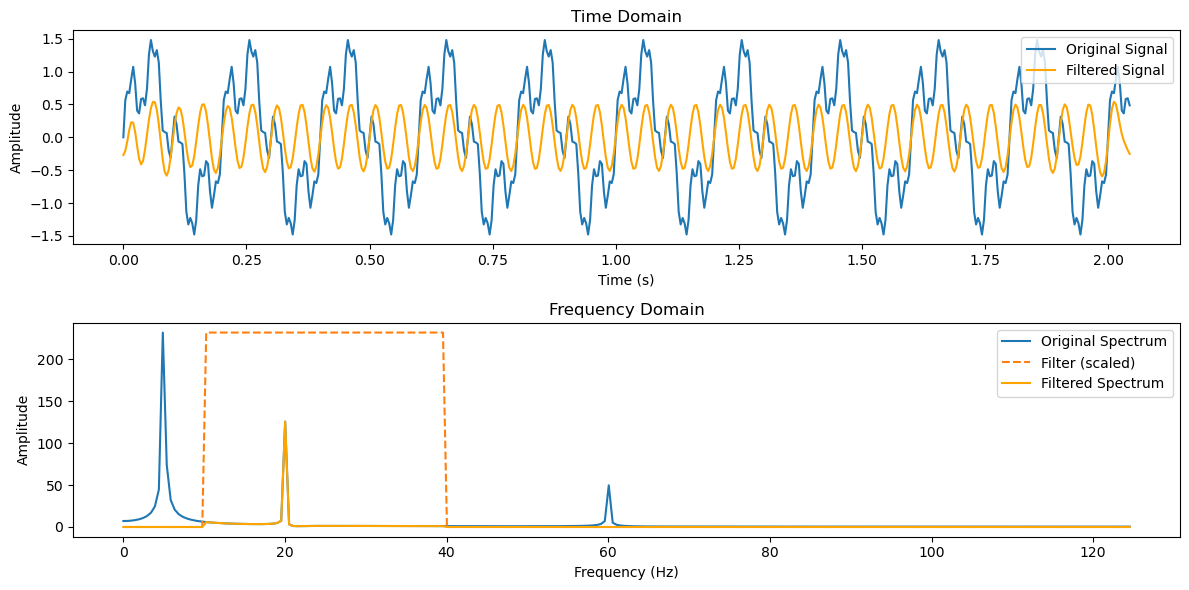

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic signal
dt = 0.004       # time step (s)
nt = 512         # number of samples
t = np.arange(nt) * dt

# Components: low, mid, and high frequencies
f1, f2, f3 = 5, 20, 60
signal = (
    np.sin(2 * np.pi * f1 * t) +
    0.5 * np.sin(2 * np.pi * f2 * t) +
    0.2 * np.sin(2 * np.pi * f3 * t)
)

# FFT and frequency axis
signal_fft = np.fft.fft(signal)
freq = np.fft.fftfreq(nt, d=dt)

# Design bandpass filter (rectangular in frequency domain)
f_low, f_high = 10, 40  # Hz
bandpass = np.zeros(nt)
bandpass[np.logical_and(np.abs(freq) >= f_low, np.abs(freq) <= f_high)] = 1.0

# Apply filter in frequency domain
filtered_fft = signal_fft * bandpass
filtered_signal = np.fft.ifft(filtered_fft).real

# Plot Time Domain
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, label='Original Signal')
plt.plot(t, filtered_signal, label='Filtered Signal', color='orange')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time Domain")
plt.legend()

# Plot Frequency Domain (only positive frequencies)
plt.subplot(2, 1, 2)
pos_mask = freq >= 0
plt.plot(freq[pos_mask], np.abs(signal_fft)[pos_mask], label='Original Spectrum')
plt.plot(freq[pos_mask], bandpass[pos_mask] * np.max(np.abs(signal_fft)), label='Filter (scaled)', linestyle='--')
plt.plot(freq[pos_mask], np.abs(filtered_fft)[pos_mask], label='Filtered Spectrum', color='orange')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain")
plt.legend()

plt.tight_layout()
plt.show()


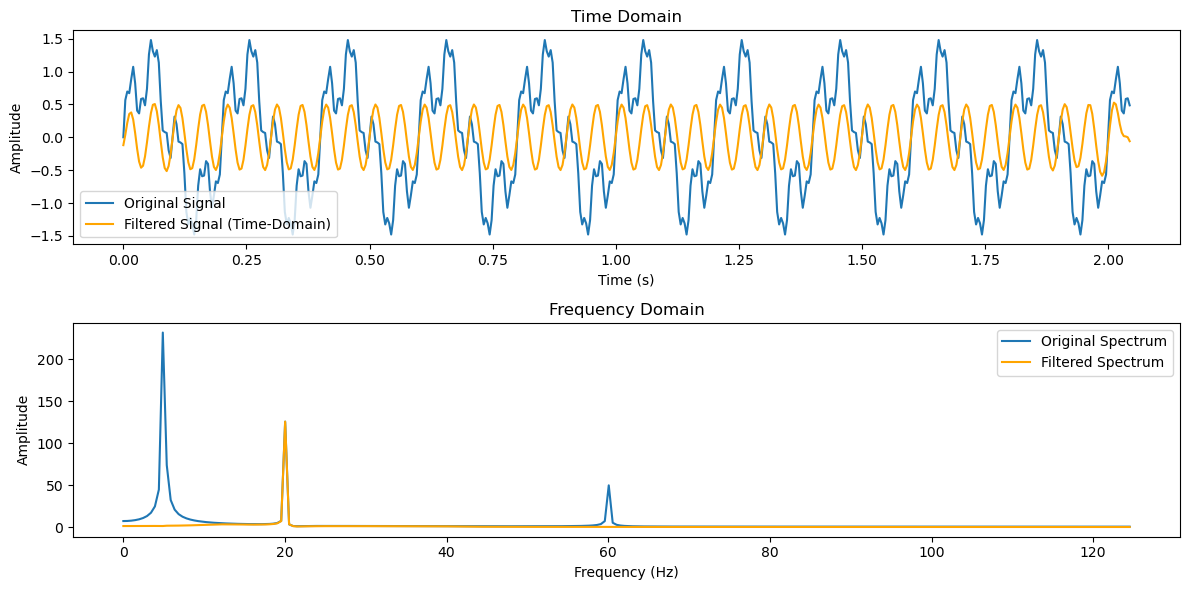

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, windows

# Time parameters
dt = 0.004
nt = 512
t = np.arange(nt) * dt

# Create synthetic signal
f1, f2, f3 = 5, 20, 60
signal = (
    np.sin(2 * np.pi * f1 * t) +
    0.5 * np.sin(2 * np.pi * f2 * t) +
    0.2 * np.sin(2 * np.pi * f3 * t)
)

# Bandpass filter parameters
f_low, f_high = 10, 40  # Hz
filter_length = 101     # odd number recommended
half_len = filter_length // 2
t_filter = np.arange(-half_len, half_len + 1) * dt

# Design lowpass and highpass filters (sinc * window)
def sinc_filter(fc, t, dt):
    """Return time-domain sinc filter with cutoff frequency fc (Hz)."""
    h = np.sinc(2 * fc * (t)) * 2 * fc * dt
    return h

lowpass = sinc_filter(f_high, t_filter, dt)
highpass = sinc_filter(f_low, t_filter, dt)

# Use window (e.g., Hamming) to taper the filter and avoid ringing
window = windows.hamming(filter_length)
lowpass *= window
highpass *= window

# Create bandpass by subtracting filters in time domain
bandpass = lowpass - highpass

# Convolve signal with bandpass filter
filtered_signal = convolve(signal, bandpass, mode='same')

# FFTs for spectral comparison
freq = np.fft.fftfreq(nt, d=dt)
signal_fft = np.fft.fft(signal)
filtered_fft = np.fft.fft(filtered_signal)

# Plot time-domain signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, label='Original Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (Time-Domain)', color='orange')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time Domain")
plt.legend()

# Plot frequency spectra (positive freqs)
plt.subplot(2, 1, 2)
pos_mask = freq >= 0
plt.plot(freq[pos_mask], np.abs(signal_fft)[pos_mask], label='Original Spectrum')
plt.plot(freq[pos_mask], np.abs(filtered_fft)[pos_mask], label='Filtered Spectrum', color='orange')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain")
plt.legend()

plt.tight_layout()
plt.show()
